# Aula 14 - SysIdentPy e modelos NARX

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import os

FIG_DIR = Path("figuras_sysidentpy")
DATA_DIR = Path("datasets_sysidentpy")
MPL_DIR = Path(".matplotlib-cache")
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
MPL_DIR.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sysidentpy.basis_function import Polynomial
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.parameter_estimation import LeastSquares, RecursiveLeastSquares
from sysidentpy.metrics import mean_absolute_error, r2_score, root_relative_squared_error
from sysidentpy.utils.display_results import results

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

URLS = {
    "f16": "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/refs/heads/main/datasets/f_16_vibration_test/f-16.txt",
    "motor_x": "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/refs/heads/main/datasets/generator/x_cc.csv",
    "motor_y": "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/refs/heads/main/datasets/generator/y_cc.csv",
    "hospital": "https://raw.githubusercontent.com/wilsonrljr/sysidentpy-data/refs/heads/main/datasets/san_francisco_hospital/SanFrancisco_Hospital.csv",
}

def get_data(key, filename):
    path = DATA_DIR / filename
    if not path.exists():
        urlretrieve(URLS[key], path)
    return path

def savefig(fig, filename):
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()

def mape_percent(y, yhat):
    y = np.asarray(y).ravel()
    yhat = np.asarray(yhat).ravel()
    error = y - yhat
    eps = max(1e-8, 0.01*np.max(np.abs(y)))
    mask = np.abs(y) > eps
    if not np.any(mask):
        mask = np.ones_like(y, dtype=bool)
    return 100*np.mean(np.abs(error[mask]/y[mask]))

def metric_table(y, yhat):
    return pd.DataFrame({
        "valor": [mape_percent(y, yhat), mean_absolute_error(y, yhat), r2_score(y, yhat)]
    }, index=["MAPE (%)", "MAE", "R²"])

## Motor-gerador

In [3]:
x_raw = pd.read_csv(get_data("motor_x", "x_cc.csv")).values
y_raw = pd.read_csv(get_data("motor_y", "y_cc.csv")).values

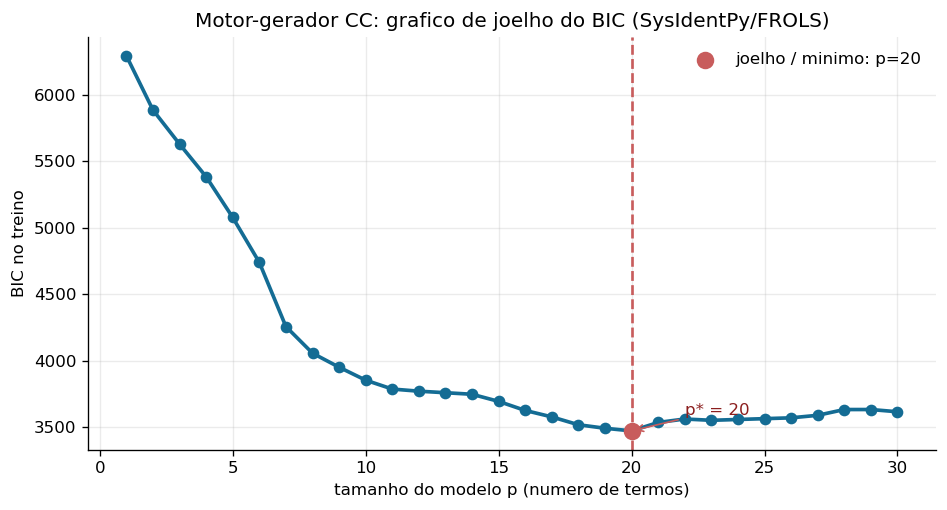

In [4]:
x_motor = x_raw[::500]
y_motor = y_raw[::500]
x_train_motor, x_valid_motor, y_train_motor, y_valid_motor = train_test_split(
    x_motor, y_motor, train_size=0.5, shuffle=False
)

model_motor_bic = FROLS(
    ylag=5,
    xlag=5,
    order_selection=True,
    n_info_values=30,
    info_criteria="bic",
    estimator=RecursiveLeastSquares(),
    basis_function=Polynomial(degree=2),
)
model_motor_bic.fit(X=x_train_motor, y=y_train_motor)
bic_motor = model_motor_bic.info_values
p = np.arange(1, len(bic_motor)+1)
p_star = int(np.nanargmin(bic_motor) + 1)

fig, ax = plt.subplots(figsize=(8.0, 4.35))
ax.plot(p, bic_motor, marker="o", linewidth=2.2, color="#146C94")
ax.axvline(p_star, color="#C85C5C", linestyle="--", linewidth=1.6)
ax.scatter([p_star], [bic_motor[p_star-1]], s=90, color="#C85C5C", zorder=3,
           label=f"joelho / minimo: p={p_star}")
ax.annotate(f"p* = {p_star}", xy=(p_star, bic_motor[p_star-1]),
            xytext=(p_star+2, bic_motor[p_star-1]+120), color="#8B1E1E",
            arrowprops=dict(arrowstyle="->", color="#C85C5C"))
ax.set_title("Motor-gerador CC: grafico de joelho do BIC (SysIdentPy/FROLS)")
ax.set_xlabel("tamanho do modelo p (numero de termos)")
ax.set_ylabel("BIC no treino")
ax.legend(loc="upper right", frameon=False)
savefig(fig, "10_bic_knee_motor_sysidentpy.png")

## F-16: predição livre no conjunto de teste

In [ ]:
f16 = pd.read_csv(get_data("f16", "f16.txt"), header=None, names=["x1", "x2", "y"])
x_f16 = f16[["x1", "x2"]].values
y_f16 = f16[["y"]].values
x_train_f16, x_valid_f16, y_train_f16, y_valid_f16 = train_test_split(
    x_f16, y_f16, train_size=8192, test_size=4096, shuffle=False
)

model_f16 = FROLS(
    ylag=12,
    xlag=[list(range(1, 7)), list(range(1, 7))],
    order_selection=True,
    n_info_values=40,
    info_criteria="bic",
    estimator=LeastSquares(),
    basis_function=Polynomial(degree=2),
)
model_f16.fit(X=x_train_f16, y=y_train_f16)
yhat_f16 = model_f16.predict(X=x_valid_f16, y=y_valid_f16, steps_ahead=None)

fig, ax = plt.subplots(figsize=(8.0, 3.2))
n = 4096
ax.plot(y_valid_f16[:n], label="medido", linewidth=1.8, color="#1f77b4")
ax.plot(yhat_f16[:n], label="predito", linewidth=1.2, color="#ff7f0e")
ax.set_title(f"F-16: predicao livre com NARX linear, RRSE = {root_relative_squared_error(y_valid_f16, yhat_f16):.3f}")
ax.set_xlabel("amostra de validacao")
ax.set_ylabel("aceleracao normalizada")
ax.legend(loc="upper right")
savefig(fig, "04_f16_fit.png")

metric_table(y_valid_f16, yhat_f16)

## Motor-gerador: sinais de entrada e saída

In [ ]:
start = 250000
step = 50
n = 1200
u_seg = x_raw.ravel()[start:start+n*step:step]
y_seg = y_raw.ravel()[start:start+n*step:step]
t = np.arange(len(u_seg))

fig, ax1 = plt.subplots(figsize=(8.2, 3.4))
line1 = ax1.step(t, u_seg, where="post", color="#146C94", linewidth=1.6, label="entrada u(k)")
ax1.set_xlabel("amostras do trecho")
ax1.set_ylabel("u(k) [V]", color="#146C94")
ax1.tick_params(axis="y", labelcolor="#146C94")
ax1.set_ylim(-0.3, 5.3)

ax2 = ax1.twinx()
line2 = ax2.plot(t, y_seg, color="#C85C5C", linewidth=1.2, alpha=0.9, label="saida y(k)")
ax2.set_ylabel("y(k) [mV]", color="#C85C5C")
ax2.tick_params(axis="y", labelcolor="#C85C5C")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=9)
ax1.set_title("Motor-gerador: trecho dos sinais de entrada e saida")
savefig(fig, "05_motor_signals.png")

## Motor-gerador: predição livre no conjunto de teste

In [ ]:
# A base polinomial de grau 2 envolve produtos de regressores; por isso normalizamos
# antes do ajuste e depois voltamos a escala da saída para mV.
x_scaler = StandardScaler()
y_scaler = StandardScaler()
x_train_scaled = x_scaler.fit_transform(x_train_motor)
x_valid_scaled = x_scaler.transform(x_valid_motor)
y_train_scaled = y_scaler.fit_transform(y_train_motor)
y_valid_scaled = y_scaler.transform(y_valid_motor)

model_motor = FROLS(
    ylag=5,
    xlag=5,
    order_selection=True,
    n_info_values=30,
    info_criteria="bic",
    estimator=LeastSquares(),
    basis_function=Polynomial(degree=2),
)
model_motor.fit(X=x_train_scaled, y=y_train_scaled)
yhat_motor_scaled = model_motor.predict(X=x_valid_scaled, y=y_valid_scaled, steps_ahead=None)
yhat_motor = y_scaler.inverse_transform(yhat_motor_scaled)

fig, ax = plt.subplots(figsize=(8.0, 3.2))
n = 450
ax.plot(y_valid_motor[:n], label="medido", linewidth=1.8, color="#1f77b4")
ax.plot(yhat_motor[:n], label="predito", linewidth=1.2, color="#ff7f0e")
ax.set_title(f"Motor-gerador: predicao livre NARX, RRSE = {root_relative_squared_error(y_valid_motor, yhat_motor):.3f}")
ax.set_xlabel("amostra de validacao")
ax.set_ylabel("saida")
ax.legend(loc="lower left")
savefig(fig, "06_motor_fit.png")

metric_table(y_valid_motor, yhat_motor)

## Carga hospitalar: FROLS/BIC e predição livre

In [ ]:
hospital = pd.read_csv(get_data("hospital", "SanFrancisco_Hospital.csv"))
y_load = hospital.iloc[:, 0].astype(float).values.reshape(-1, 1)
y_train_load, y_valid_load = train_test_split(
    y_load, train_size=0.7, shuffle=False
)
ylags_load = list(range(1, 11)) + [24, 25, 168, 169]

model_load_knee = FROLS(
    ylag=ylags_load,
    model_type="NAR",
    order_selection=False,
    n_terms=3,
    n_info_values=15,
    info_criteria="bic",
    estimator=LeastSquares(),
    basis_function=Polynomial(degree=1),
)
model_load_knee.fit(X=None, y=y_train_load)
yhat_load_knee = model_load_knee.predict(
    X=None, y=y_valid_load, steps_ahead=None, forecast_horizon=len(y_valid_load)
)[:len(y_valid_load)]

model_load_bic = FROLS(
    ylag=ylags_load,
    model_type="NAR",
    order_selection=True,
    n_info_values=15,
    info_criteria="bic",
    estimator=LeastSquares(),
    basis_function=Polynomial(degree=1),
)
model_load_bic.fit(X=None, y=y_train_load)
yhat_load_bic = model_load_bic.predict(
    X=None, y=y_valid_load, steps_ahead=None, forecast_horizon=len(y_valid_load)
)[:len(y_valid_load)]

bic_load = model_load_bic.info_values
p = np.arange(1, len(bic_load)+1)
p_knee = 3
p_min = int(np.nanargmin(bic_load)+1)

fig, ax = plt.subplots(2, 1, figsize=(8.0, 5.56))
ax[0].plot(p, bic_load, linewidth=2.0, color="#146C94")
ax[0].scatter([p_knee], [bic_load[p_knee-1]], s=80, color="#3A6B35", zorder=3, label="joelho: p=3")
ax[0].scatter([p_min], [bic_load[p_min-1]], s=80, color="#C85C5C", zorder=3, label=f"menor BIC: p={p_min}")
ax[0].set_title("Carga hospitalar: BIC ao longo da ordem FROLS")
ax[0].set_ylabel("BIC")
ax[0].set_xlabel("termos inseridos pelo FROLS (inclui constante)")
ax[0].legend(loc="upper right")

n = 500
t = np.arange(n)
rrse_knee = root_relative_squared_error(y_valid_load, yhat_load_knee)
rrse_bic = root_relative_squared_error(y_valid_load, yhat_load_bic)
ax[1].plot(t, y_valid_load[:n], linewidth=1.8, color="#146C94", label="teste medido")
ax[1].plot(t, yhat_load_knee[:n], linewidth=1.4, color="#3A6B35", label="joelho p=3")
ax[1].plot(t, yhat_load_bic[:n], linewidth=1.2, color="#C85C5C", label=f"menor BIC p={p_min}")
ax[1].set_title(f"Predicao livre: RRSE joelho {rrse_knee:.3f}; menor BIC {rrse_bic:.3f}")
ax[1].set_xlabel("amostras de teste")
ax[1].set_ylabel("kW")
ax[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
savefig(fig, "08_hospital_bic_prediction.png")

pd.DataFrame({
    "modelo": ["joelho p=3", f"menor BIC p={p_min}"],
    "MAPE (%)": [mape_percent(y_valid_load, yhat_load_knee), mape_percent(y_valid_load, yhat_load_bic)],
    "MAE": [mean_absolute_error(y_valid_load, yhat_load_knee), mean_absolute_error(y_valid_load, yhat_load_bic)],
    "R²": [r2_score(y_valid_load, yhat_load_knee), r2_score(y_valid_load, yhat_load_bic)],
})